<a href="https://colab.research.google.com/github/irungugraceig-sudo/4d-perception-engine/blob/main/Life_Expectancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Life Expectancy Data.csv to Life Expectancy Data (1).csv


In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv('Life Expectancy Data.csv')

# Just see what we have
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

Shape: (2938, 22)

Column names:
['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']

First 3 rows:
       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0      

In [ ]:
#Drop rows with missing target variable
df = df[df['Life expectancy '].notna()]

# Drop all rows with any missing values
df = df.dropna()

print(f"\nAfter cleaning: {len(df)} rows")



After cleaning: 1649 rows


In [ ]:
import pandas as pd
import numpy as np

print("="*80)
print("LIFE EXPECTANCY DATA - INITIAL ANALYSIS")
print("="*80)

# 1. Dataset size
print(f"\n📊 Dataset Size: {df.shape[0]} rows × {df.shape[1]} columns")

# 2. Column overview
print("\n📋 COLUMNS:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. '{col}'")

# 3. Target variable
print("\n🎯 TARGET VARIABLE: 'Life expectancy '")
print(f"   Mean: {df['Life expectancy '].mean():.2f} years")
print(f"   Range: {df['Life expectancy '].min():.1f} - {df['Life expectancy '].max():.1f} years")
print(f"   Missing values: {df['Life expectancy '].isnull().sum()}")

# 4. Time and geography
print(f"\n📅 DATA COVERAGE:")
print(f"   Years: {df['Year'].min()} to {df['Year'].max()}")
print(f"   Countries: {df['Country'].nunique()} unique countries")
print(f"\n🌍 Country Status:")
print(df['Status'].value_counts())

# 5. Missing values
print("\n❓ MISSING VALUES:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_df)

LIFE EXPECTANCY DATA - INITIAL ANALYSIS

📊 Dataset Size: 2938 rows × 22 columns

📋 COLUMNS:
 1. 'Country'
 2. 'Year'
 3. 'Status'
 4. 'Life expectancy '
 5. 'Adult Mortality'
 6. 'infant deaths'
 7. 'Alcohol'
 8. 'percentage expenditure'
 9. 'Hepatitis B'
10. 'Measles '
11. ' BMI '
12. 'under-five deaths '
13. 'Polio'
14. 'Total expenditure'
15. 'Diphtheria '
16. ' HIV/AIDS'
17. 'GDP'
18. 'Population'
19. ' thinness  1-19 years'
20. ' thinness 5-9 years'
21. 'Income composition of resources'
22. 'Schooling'

🎯 TARGET VARIABLE: 'Life expectancy '
   Mean: 69.22 years
   Range: 36.3 - 89.0 years
   Missing values: 10

📅 DATA COVERAGE:
   Years: 2000 to 2015
   Countries: 193 unique countries

🌍 Country Status:
Status
Developing    2426
Developed      512
Name: count, dtype: int64

❓ MISSING VALUES:
                                 Count  Percentage
Population                         652   22.191967
Hepatitis B                        553   18.822328
GDP                                448 

STEP 2A: UNDERSTANDING LIFE EXPECTANCY (TARGET VARIABLE)

📊 BASIC STATISTICS:
   Count: 2928 (out of 2938 total)
   Mean: 69.22 years
   Median: 72.10 years
   Std Dev: 9.52 years
   Min: 36.3 years
   Max: 89.0 years
   Range: 52.7 years

📈 QUARTILES:
   25th percentile (Q1): 63.10 years
   50th percentile (Q2/Median): 72.10 years
   75th percentile (Q3): 75.70 years
   IQR (Q3-Q1): 12.60 years


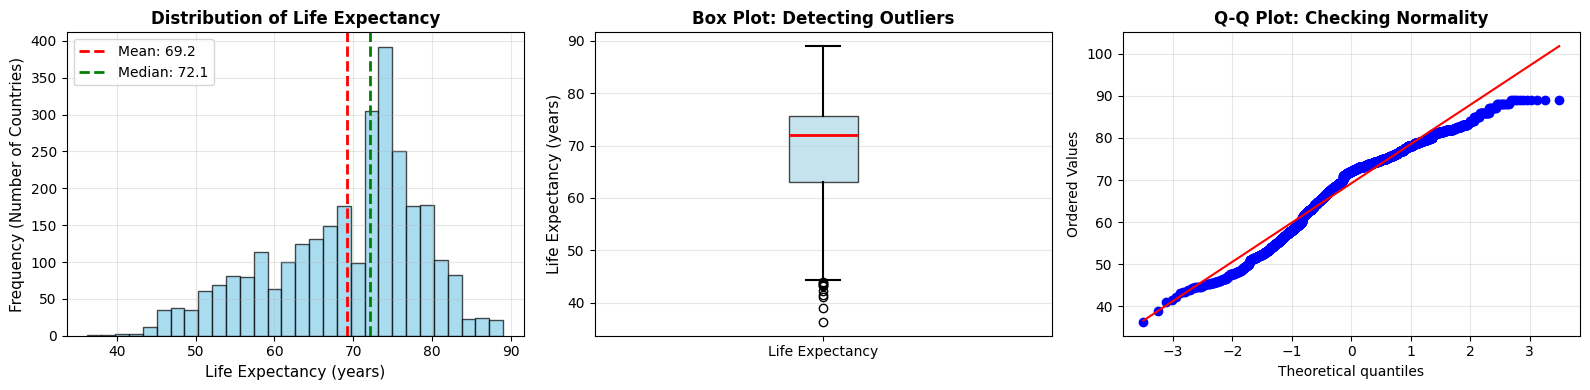


📐 DISTRIBUTION SHAPE:
   Skewness: -0.639
      → Left-skewed (tail extends to the left)
   Kurtosis: -0.234
      → Normal distribution (mesokurtic)

🔬 NORMALITY TEST (Shapiro-Wilk):
   Statistic: 0.9560
   P-value: 0.0000
   ⚠️  Interpretation: Data is NOT normally distributed (p < 0.05)
      (This is okay! Linear regression is robust to non-normality of predictors)

🎯 OUTLIER DETECTION:
   Lower bound: 44.20 years
   Upper bound: 94.60 years
   Number of outliers: 10
   Outlier countries (showing first 10):
      Haiti (2010): 36.3 years
      Malawi (2002): 44.0 years
      Malawi (2001): 43.5 years
      Malawi (2000): 43.1 years
      Sierra Leone (2005): 43.3 years
      Sierra Leone (2004): 42.3 years
      Sierra Leone (2003): 41.5 years
      Sierra Leone (2001): 41.0 years
      Sierra Leone (2000): 39.0 years
      Zambia (2000): 43.8 years

✅ STEP 2A COMPLETE!

KEY QUESTIONS TO ANSWER:
1. Is the distribution roughly normal (bell-shaped)?
2. Are there extreme outliers we 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("="*80)
print("STEP 2A: UNDERSTANDING LIFE EXPECTANCY (TARGET VARIABLE)")
print("="*80)

# Basic statistics
print("\n📊 BASIC STATISTICS:")
print(f"   Count: {df['Life expectancy '].count()} (out of {len(df)} total)")
print(f"   Mean: {df['Life expectancy '].mean():.2f} years")
print(f"   Median: {df['Life expectancy '].median():.2f} years")
print(f"   Std Dev: {df['Life expectancy '].std():.2f} years")
print(f"   Min: {df['Life expectancy '].min():.1f} years")
print(f"   Max: {df['Life expectancy '].max():.1f} years")
print(f"   Range: {df['Life expectancy '].max() - df['Life expectancy '].min():.1f} years")

# Quartiles
print("\n📈 QUARTILES:")
print(f"   25th percentile (Q1): {df['Life expectancy '].quantile(0.25):.2f} years")
print(f"   50th percentile (Q2/Median): {df['Life expectancy '].quantile(0.50):.2f} years")
print(f"   75th percentile (Q3): {df['Life expectancy '].quantile(0.75):.2f} years")
print(f"   IQR (Q3-Q1): {df['Life expectancy '].quantile(0.75) - df['Life expectancy '].quantile(0.25):.2f} years")

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. HISTOGRAM
axes[0].hist(df['Life expectancy '].dropna(), bins=30, edgecolor='black',
             alpha=0.7, color='skyblue')
axes[0].axvline(df['Life expectancy '].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {df["Life expectancy "].mean():.1f}')
axes[0].axvline(df['Life expectancy '].median(), color='green', linestyle='--',
                linewidth=2, label=f'Median: {df["Life expectancy "].median():.1f}')
axes[0].set_xlabel('Life Expectancy (years)', fontsize=11)
axes[0].set_ylabel('Frequency (Number of Countries)', fontsize=11)
axes[0].set_title('Distribution of Life Expectancy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. BOX PLOT
box = axes[1].boxplot(df['Life expectancy '].dropna(), vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(linewidth=1.5),
                      capprops=dict(linewidth=1.5))
axes[1].set_ylabel('Life Expectancy (years)', fontsize=11)
axes[1].set_title('Box Plot: Detecting Outliers', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticklabels(['Life Expectancy'])

# 3. Q-Q PLOT (Normality test)
stats.probplot(df['Life expectancy '].dropna(), dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot: Checking Normality', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Shape analysis
print("\n📐 DISTRIBUTION SHAPE:")
skewness = df['Life expectancy '].skew()
kurtosis = df['Life expectancy '].kurtosis()
print(f"   Skewness: {skewness:.3f}")
if abs(skewness) < 0.5:
    print("      → Approximately symmetric")
elif skewness < 0:
    print("      → Left-skewed (tail extends to the left)")
else:
    print("      → Right-skewed (tail extends to the right)")

print(f"   Kurtosis: {kurtosis:.3f}")
if abs(kurtosis) < 0.5:
    print("      → Normal distribution (mesokurtic)")
elif kurtosis > 0:
    print("      → Heavy-tailed, more outliers (leptokurtic)")
else:
    print("      → Light-tailed, fewer outliers (platykurtic)")

# Normality test
sample = df['Life expectancy '].dropna().sample(min(5000, len(df['Life expectancy '].dropna())))
stat, p_value = stats.shapiro(sample)
print(f"\n🔬 NORMALITY TEST (Shapiro-Wilk):")
print(f"   Statistic: {stat:.4f}")
print(f"   P-value: {p_value:.4f}")
if p_value < 0.05:
    print("   ⚠️  Interpretation: Data is NOT normally distributed (p < 0.05)")
    print("      (This is okay! Linear regression is robust to non-normality of predictors)")
else:
    print("   ✅ Interpretation: Data appears normally distributed (p >= 0.05)")

# Outlier detection
Q1 = df['Life expectancy '].quantile(0.25)
Q3 = df['Life expectancy '].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Life expectancy '] < lower_bound) | (df['Life expectancy '] > upper_bound)]

print(f"\n🎯 OUTLIER DETECTION:")
print(f"   Lower bound: {lower_bound:.2f} years")
print(f"   Upper bound: {upper_bound:.2f} years")
print(f"   Number of outliers: {len(outliers)}")
if len(outliers) > 0:
    print(f"   Outlier countries (showing first 10):")
    for idx, row in outliers.head(10).iterrows():
        print(f"      {row['Country']} ({row['Year']}): {row['Life expectancy ']:.1f} years")

print("\n" + "="*80)
print("✅ STEP 2A COMPLETE!")
print("\nKEY QUESTIONS TO ANSWER:")
print("1. Is the distribution roughly normal (bell-shaped)?")
print("2. Are there extreme outliers we should investigate?")
print("3. What's the typical range of life expectancy?")
print("="*80)

STEP 2B: DEVELOPED vs DEVELOPING COUNTRIES

📊 SUMMARY STATISTICS:

Developed Countries:
   Count: 512
   Mean: 79.20 years
   Median: 79.25 years
   Std Dev: 3.93 years
   Range: 69.9 - 89.0 years

Developing Countries:
   Count: 2416
   Mean: 67.11 years
   Median: 69.00 years
   Std Dev: 9.01 years
   Range: 36.3 - 89.0 years

🔍 COMPARISON:
   Mean difference: 12.09 years
   Median difference: 10.25 years
   Developed countries live 12.1 years longer on average!


/tmp/ipython-input-723916749.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 0].boxplot([developed, developing], labels=['Developed', 'Developing'],


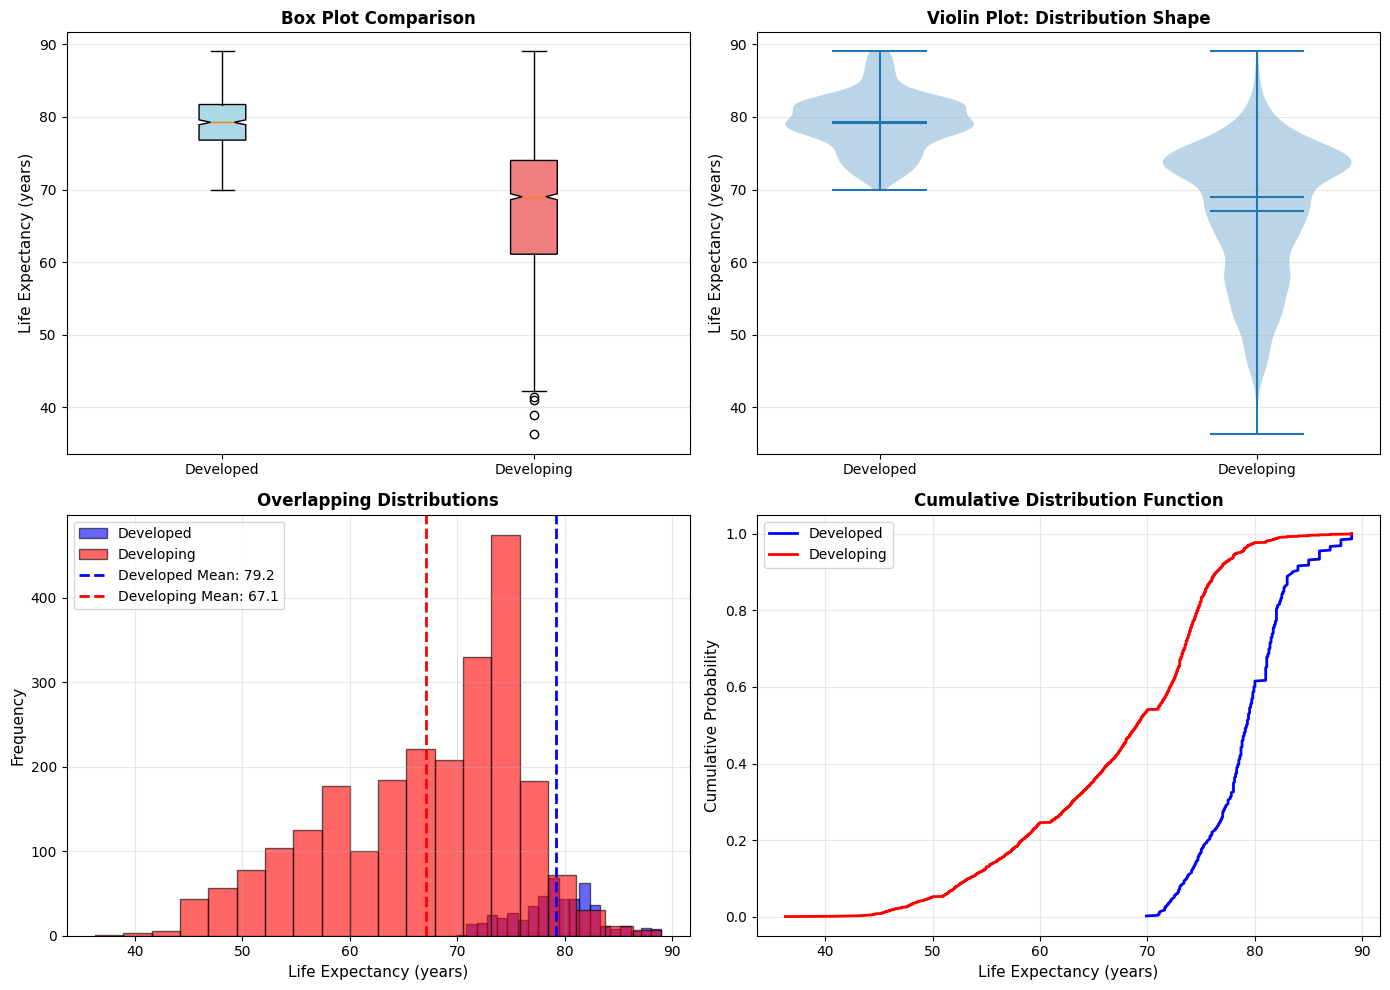


🔬 STATISTICAL TESTS:

1. Two-Sample T-Test:
   Null Hypothesis: Means are equal
   T-statistic: 29.768
   P-value: 0.000000
   ✅ REJECT null hypothesis (p < 0.05)
      → Means are SIGNIFICANTLY different

2. Mann-Whitney U Test (non-parametric):
   Null Hypothesis: Distributions are equal
   U-statistic: 1131521.000
   P-value: 0.000000
   ✅ REJECT null hypothesis (p < 0.05)
      → Distributions are SIGNIFICANTLY different

3. Effect Size (Cohen's d):
   Cohen's d: 1.448
   → Large effect (meaningful difference!)


KEY TAKEAWAY:
Developed countries have 12.1 years higher life expectancy on average.
This difference is statistically significant and practically meaningful!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("="*80)
print("STEP 2B: DEVELOPED vs DEVELOPING COUNTRIES")
print("="*80)

# Split data by status
developed = df[df['Status'] == 'Developed']['Life expectancy '].dropna()
developing = df[df['Status'] == 'Developing']['Life expectancy '].dropna()

# Summary statistics
print("\n📊 SUMMARY STATISTICS:")
print("\nDeveloped Countries:")
print(f"   Count: {len(developed)}")
print(f"   Mean: {developed.mean():.2f} years")
print(f"   Median: {developed.median():.2f} years")
print(f"   Std Dev: {developed.std():.2f} years")
print(f"   Range: {developed.min():.1f} - {developed.max():.1f} years")

print("\nDeveloping Countries:")
print(f"   Count: {len(developing)}")
print(f"   Mean: {developing.mean():.2f} years")
print(f"   Median: {developing.median():.2f} years")
print(f"   Std Dev: {developing.std():.2f} years")
print(f"   Range: {developing.min():.1f} - {developing.max():.1f} years")

print("\n🔍 COMPARISON:")
diff_mean = developed.mean() - developing.mean()
diff_median = developed.median() - developing.median()
print(f"   Mean difference: {diff_mean:.2f} years")
print(f"   Median difference: {diff_median:.2f} years")
print(f"   Developed countries live {diff_mean:.1f} years longer on average!")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box Plot Comparison
bp = axes[0, 0].boxplot([developed, developing], labels=['Developed', 'Developing'],
                         patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0, 0].set_ylabel('Life Expectancy (years)', fontsize=11)
axes[0, 0].set_title('Box Plot Comparison', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Violin Plot
parts = axes[0, 1].violinplot([developed, developing], positions=[1, 2],
                               showmeans=True, showmedians=True)
axes[0, 1].set_xticks([1, 2])
axes[0, 1].set_xticklabels(['Developed', 'Developing'])
axes[0, 1].set_ylabel('Life Expectancy (years)', fontsize=11)
axes[0, 1].set_title('Violin Plot: Distribution Shape', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Overlapping Histograms
axes[1, 0].hist(developed, bins=20, alpha=0.6, label='Developed', color='blue', edgecolor='black')
axes[1, 0].hist(developing, bins=20, alpha=0.6, label='Developing', color='red', edgecolor='black')
axes[1, 0].axvline(developed.mean(), color='blue', linestyle='--', linewidth=2,
                   label=f'Developed Mean: {developed.mean():.1f}')
axes[1, 0].axvline(developing.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Developing Mean: {developing.mean():.1f}')
axes[1, 0].set_xlabel('Life Expectancy (years)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Overlapping Distributions', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative Distribution
developed_sorted = np.sort(developed)
developing_sorted = np.sort(developing)
developed_cdf = np.arange(1, len(developed_sorted) + 1) / len(developed_sorted)
developing_cdf = np.arange(1, len(developing_sorted) + 1) / len(developing_sorted)

axes[1, 1].plot(developed_sorted, developed_cdf, label='Developed', linewidth=2, color='blue')
axes[1, 1].plot(developing_sorted, developing_cdf, label='Developing', linewidth=2, color='red')
axes[1, 1].set_xlabel('Life Expectancy (years)', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=11)
axes[1, 1].set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical Tests
print("\n🔬 STATISTICAL TESTS:")

# 1. Two-sample t-test (tests if means are different)
t_stat, p_val_ttest = stats.ttest_ind(developed, developing)
print(f"\n1. Two-Sample T-Test:")
print(f"   Null Hypothesis: Means are equal")
print(f"   T-statistic: {t_stat:.3f}")
print(f"   P-value: {p_val_ttest:.6f}")
if p_val_ttest < 0.05:
    print(f"   ✅ REJECT null hypothesis (p < 0.05)")
    print(f"      → Means are SIGNIFICANTLY different")
else:
    print(f"   ❌ FAIL TO REJECT null hypothesis (p >= 0.05)")
    print(f"      → No significant difference in means")

# 2. Mann-Whitney U test (non-parametric alternative)
u_stat, p_val_mann = stats.mannwhitneyu(developed, developing, alternative='two-sided')
print(f"\n2. Mann-Whitney U Test (non-parametric):")
print(f"   Null Hypothesis: Distributions are equal")
print(f"   U-statistic: {u_stat:.3f}")
print(f"   P-value: {p_val_mann:.6f}")
if p_val_mann < 0.05:
    print(f"   ✅ REJECT null hypothesis (p < 0.05)")
    print(f"      → Distributions are SIGNIFICANTLY different")
else:
    print(f"   ❌ FAIL TO REJECT null hypothesis (p >= 0.05)")

# 3. Effect size (Cohen's d)
pooled_std = np.sqrt(((len(developed)-1)*developed.std()**2 +
                      (len(developing)-1)*developing.std()**2) /
                     (len(developed) + len(developing) - 2))
cohens_d = (developed.mean() - developing.mean()) / pooled_std
print(f"\n3. Effect Size (Cohen's d):")
print(f"   Cohen's d: {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    print(f"   → Small effect")
elif abs(cohens_d) < 0.5:
    print(f"   → Medium effect")
else:
    print(f"   → Large effect (meaningful difference!)")

print("\n" + "="*80)
print("\nKEY TAKEAWAY:")
print(f"Developed countries have {diff_mean:.1f} years higher life expectancy on average.")
print("This difference is statistically significant and practically meaningful!")
print("="*80)

STEP 2C: LIFE EXPECTANCY TRENDS OVER TIME (2000-2015)

📅 YEAR-BY-YEAR SUMMARY:
           Mean   Min   Max    Std Dev  Range
Year                                         
2000  66.750273  39.0  81.1  10.295528   42.1
2001  67.128962  41.0  82.0  10.189630   41.0
2002  67.351366  44.0  84.0  10.062469   40.0
2003  67.433333  41.5  87.0  10.127681   45.5
2004  67.646448  42.3  89.0  10.126409   46.7
2005  68.209290  43.3  88.0   9.799516   44.7
2006  68.667760  44.3  88.0   9.815171   43.7
2007  69.036066  45.3  89.0   9.618584   43.7
2008  69.427869  46.2  89.0   9.202612   42.8
2009  69.938251  47.1  89.0   8.989124   41.9
2010  70.048634  36.3  89.0   9.302959   52.7
2011  70.654098  48.9  88.0   8.925040   39.1
2012  70.916940  49.7  88.0   8.562151   38.3
2013  71.236066  49.9  87.0   8.413771   37.1
2014  71.536612  48.1  89.0   8.560831   40.9
2015  71.616940  51.0  88.0   8.123706   37.0

📈 OVERALL CHANGE:
   2000: 66.75 years
   2015: 71.62 years
   Total increase: +4.87 years
 

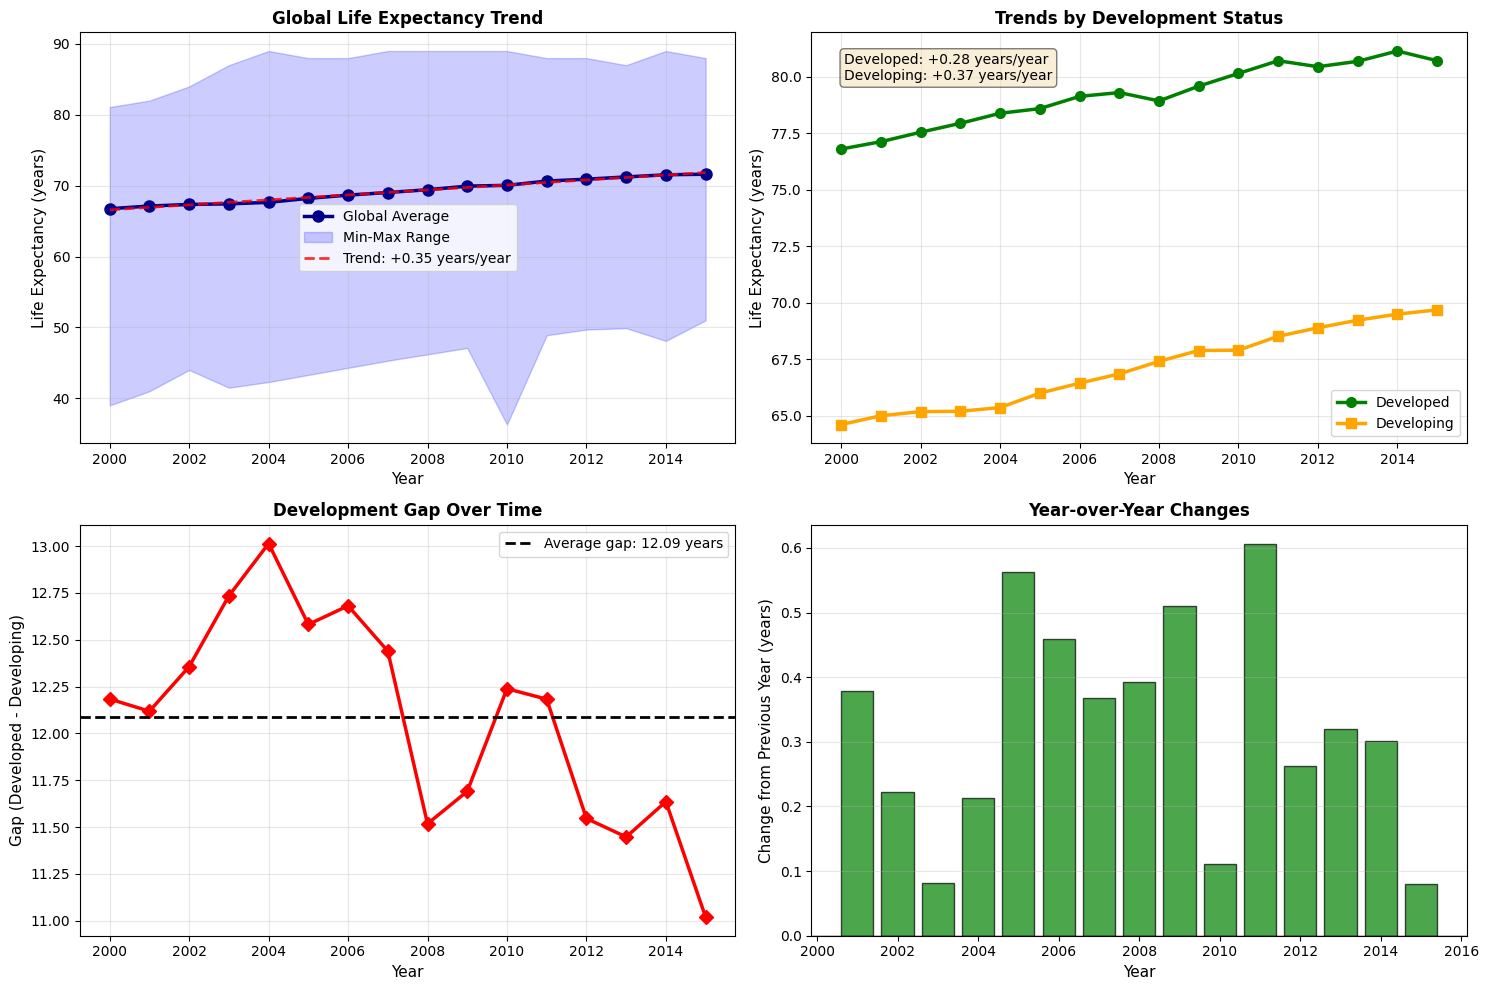


🔬 TREND ANALYSIS:

1. Global Trend:
   Slope: +0.351 years/year
   R-squared: 0.9904
   P-value: 0.000000
   ✅ Significant upward trend (p < 0.05)

2. Developed Countries Trend:
   Slope: +0.283 years/year
   P-value: 0.000000

3. Developing Countries Trend:
   Slope: +0.366 years/year
   P-value: 0.000000

4. Development Gap Trend:
   Slope: -0.082 years/year
   P-value: 0.002381
   ✅ Gap is NARROWING over time

✅ STEP 2C COMPLETE!

KEY INSIGHTS:
- Global life expectancy increased by 4.87 years (2000-2015)
- Developing countries improving faster: +0.37 vs +0.28 years/year
- But the gap remains large: average 12.1 years difference


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("="*80)
print("STEP 2C: LIFE EXPECTANCY TRENDS OVER TIME (2000-2015)")
print("="*80)

# Calculate yearly averages
yearly_avg = df.groupby('Year')['Life expectancy '].mean()
yearly_min = df.groupby('Year')['Life expectancy '].min()
yearly_max = df.groupby('Year')['Life expectancy '].max()
yearly_std = df.groupby('Year')['Life expectancy '].std()

print("\n📅 YEAR-BY-YEAR SUMMARY:")
summary_table = pd.DataFrame({
    'Mean': yearly_avg,
    'Min': yearly_min,
    'Max': yearly_max,
    'Std Dev': yearly_std,
    'Range': yearly_max - yearly_min
})
print(summary_table)

print("\n📈 OVERALL CHANGE:")
initial_year = yearly_avg.iloc[0]
final_year = yearly_avg.iloc[-1]
total_change = final_year - initial_year
pct_change = (total_change / initial_year) * 100
annual_rate = total_change / (len(yearly_avg) - 1)

print(f"   2000: {initial_year:.2f} years")
print(f"   2015: {final_year:.2f} years")
print(f"   Total increase: +{total_change:.2f} years")
print(f"   Percentage increase: +{pct_change:.2f}%")
print(f"   Average annual increase: +{annual_rate:.2f} years/year")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Overall Global Trend
axes[0, 0].plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=2.5,
                markersize=8, color='darkblue', label='Global Average')
axes[0, 0].fill_between(yearly_avg.index, yearly_min, yearly_max, alpha=0.2,
                         color='blue', label='Min-Max Range')
axes[0, 0].set_xlabel('Year', fontsize=11)
axes[0, 0].set_ylabel('Life Expectancy (years)', fontsize=11)
axes[0, 0].set_title('Global Life Expectancy Trend', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Add trend line
z = np.polyfit(yearly_avg.index, yearly_avg.values, 1)
p = np.poly1d(z)
axes[0, 0].plot(yearly_avg.index, p(yearly_avg.index), "r--",
                linewidth=2, alpha=0.8, label=f'Trend: +{z[0]:.2f} years/year')
axes[0, 0].legend()

# 2. By Development Status
yearly_status = df.groupby(['Year', 'Status'])['Life expectancy '].mean().unstack()

axes[0, 1].plot(yearly_status.index, yearly_status['Developed'],
                marker='o', label='Developed', linewidth=2.5, markersize=7, color='green')
axes[0, 1].plot(yearly_status.index, yearly_status['Developing'],
                marker='s', label='Developing', linewidth=2.5, markersize=7, color='orange')
axes[0, 1].set_xlabel('Year', fontsize=11)
axes[0, 1].set_ylabel('Life Expectancy (years)', fontsize=11)
axes[0, 1].set_title('Trends by Development Status', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Calculate slopes for each group
developed_years = yearly_status.index
developed_values = yearly_status['Developed'].values
developing_values = yearly_status['Developing'].values

slope_dev = np.polyfit(developed_years, developed_values, 1)[0]
slope_devping = np.polyfit(developed_years, developing_values, 1)[0]

axes[0, 1].text(0.05, 0.95, f'Developed: +{slope_dev:.2f} years/year\nDeveloping: +{slope_devping:.2f} years/year',
                transform=axes[0, 1].transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Gap Over Time
gap = yearly_status['Developed'] - yearly_status['Developing']
axes[1, 0].plot(gap.index, gap.values, marker='D', linewidth=2.5,
                markersize=7, color='red')
axes[1, 0].axhline(y=gap.mean(), color='black', linestyle='--',
                   linewidth=2, label=f'Average gap: {gap.mean():.2f} years')
axes[1, 0].set_xlabel('Year', fontsize=11)
axes[1, 0].set_ylabel('Gap (Developed - Developing)', fontsize=11)
axes[1, 0].set_title('Development Gap Over Time', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Year-over-year change
yearly_change = yearly_avg.diff()
axes[1, 1].bar(yearly_change.index[1:], yearly_change.values[1:],
               color=['green' if x > 0 else 'red' for x in yearly_change.values[1:]],
               alpha=0.7, edgecolor='black')
axes[1, 1].axhline(y=0, color='black', linewidth=1)
axes[1, 1].set_xlabel('Year', fontsize=11)
axes[1, 1].set_ylabel('Change from Previous Year (years)', fontsize=11)
axes[1, 1].set_title('Year-over-Year Changes', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical trend test
print("\n🔬 TREND ANALYSIS:")

# Linear regression for trend
slope, intercept, r_value, p_value, std_err = stats.linregress(yearly_avg.index, yearly_avg.values)
print(f"\n1. Global Trend:")
print(f"   Slope: +{slope:.3f} years/year")
print(f"   R-squared: {r_value**2:.4f}")
print(f"   P-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"   ✅ Significant upward trend (p < 0.05)")
else:
    print(f"   ❌ No significant trend (p >= 0.05)")

# Developed countries trend
slope_dev, intercept_dev, r_dev, p_dev, _ = stats.linregress(developed_years, developed_values)
print(f"\n2. Developed Countries Trend:")
print(f"   Slope: +{slope_dev:.3f} years/year")
print(f"   P-value: {p_dev:.6f}")

# Developing countries trend
slope_devping, intercept_devping, r_devping, p_devping, _ = stats.linregress(developed_years, developing_values)
print(f"\n3. Developing Countries Trend:")
print(f"   Slope: +{slope_devping:.3f} years/year")
print(f"   P-value: {p_devping:.6f}")

# Gap trend
slope_gap, intercept_gap, r_gap, p_gap, _ = stats.linregress(gap.index, gap.values)
print(f"\n4. Development Gap Trend:")
print(f"   Slope: {slope_gap:+.3f} years/year")
print(f"   P-value: {p_gap:.6f}")
if slope_gap > 0:
    print(f"   ⚠️  Gap is WIDENING over time")
elif slope_gap < 0:
    print(f"   ✅ Gap is NARROWING over time")
else:
    print(f"   → Gap remains constant")

print("\n" + "="*80)
print("✅ STEP 2C COMPLETE!")
print("\nKEY INSIGHTS:")
print(f"- Global life expectancy increased by {total_change:.2f} years (2000-2015)")
print(f"- Developing countries improving faster: +{slope_devping:.2f} vs +{slope_dev:.2f} years/year")
print(f"- But the gap remains large: average {gap.mean():.1f} years difference")
print("="*80)

STEP 2D: CORRELATION ANALYSIS

📊 Analyzing 20 numeric variables

🎯 TOP 10 POSITIVE CORRELATIONS with Life Expectancy:
Schooling                          0.751975
Income composition of resources    0.724776
 BMI                               0.567694
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Total expenditure                  0.218086
Name: Life expectancy , dtype: float64

⚠️  TOP 5 NEGATIVE CORRELATIONS with Life Expectancy:
under-five deaths       -0.222529
 thinness 5-9 years     -0.471584
 thinness  1-19 years   -0.477183
 HIV/AIDS               -0.556556
Adult Mortality         -0.696359
Name: Life expectancy , dtype: float64

✅ 3 variables with STRONG POSITIVE correlation (r > 0.5):
   Schooling: 0.752
   Income composition of resources: 0.725
    BMI : 0.568

❌

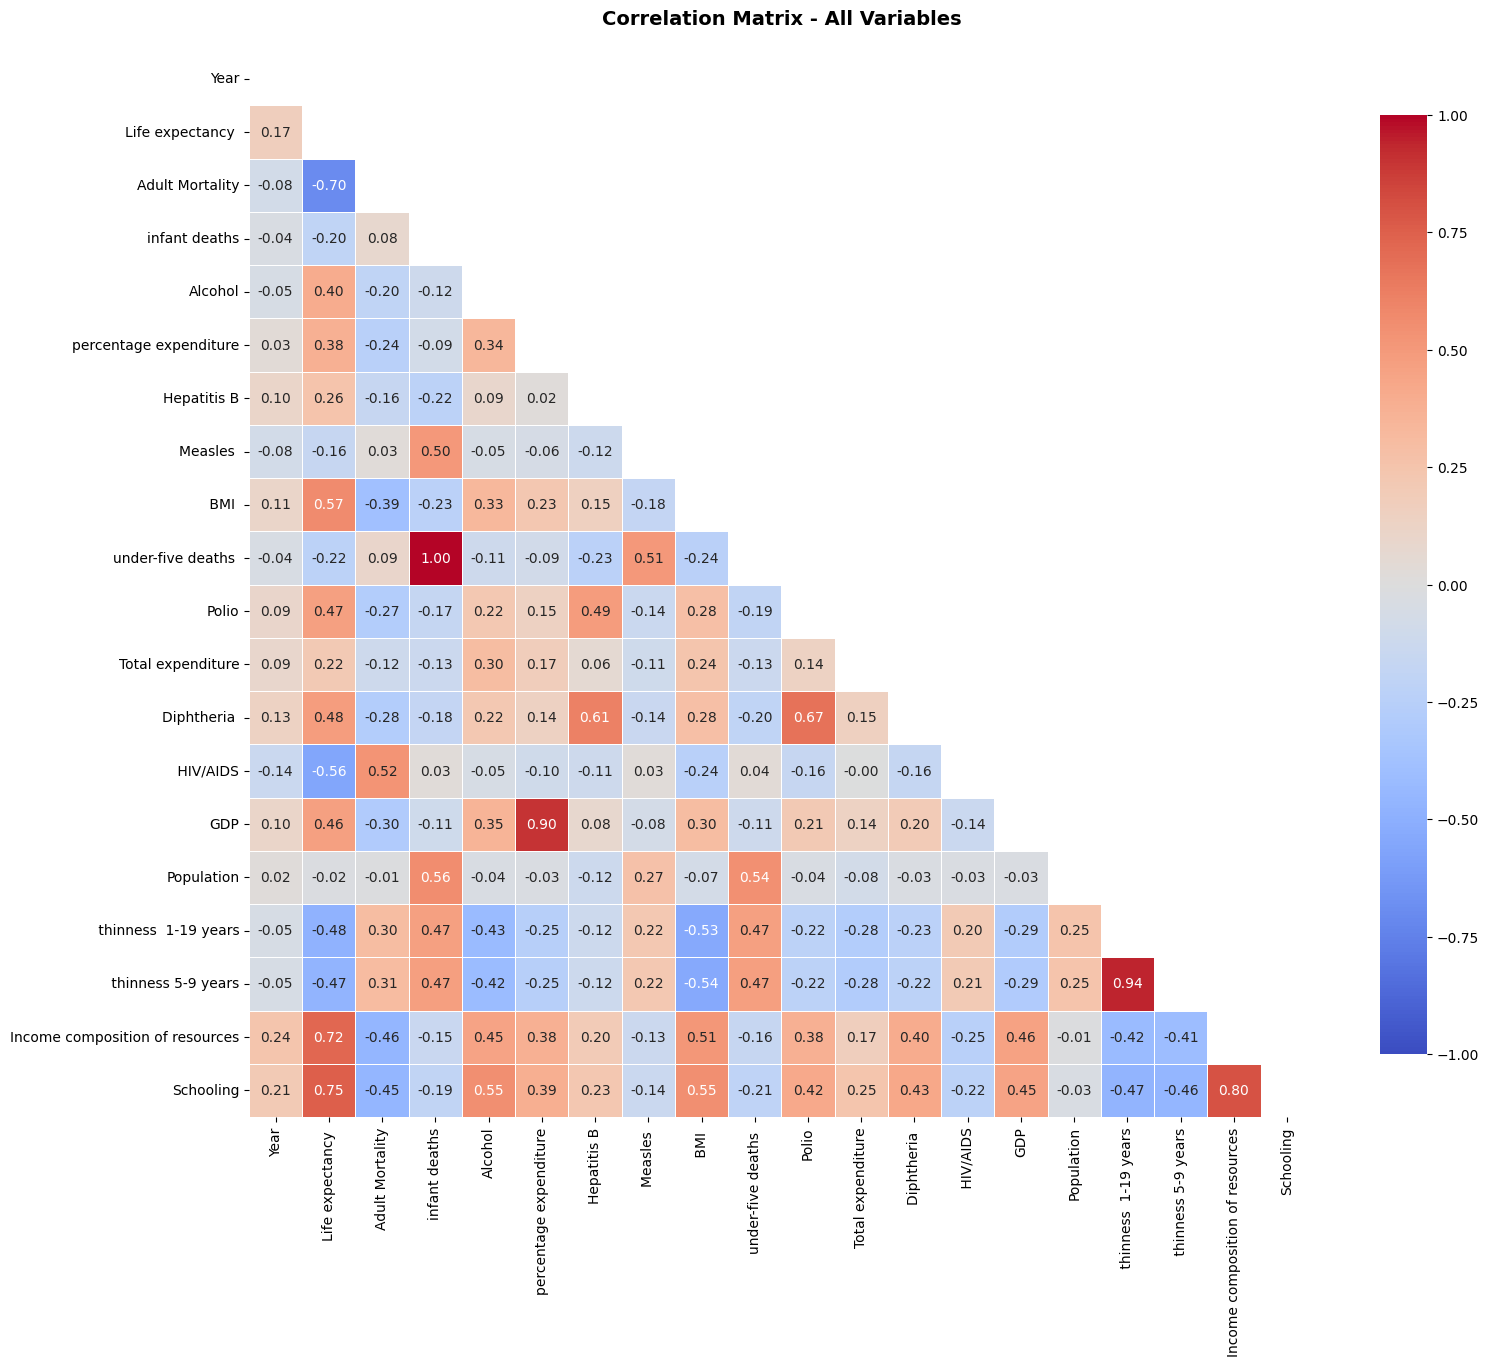

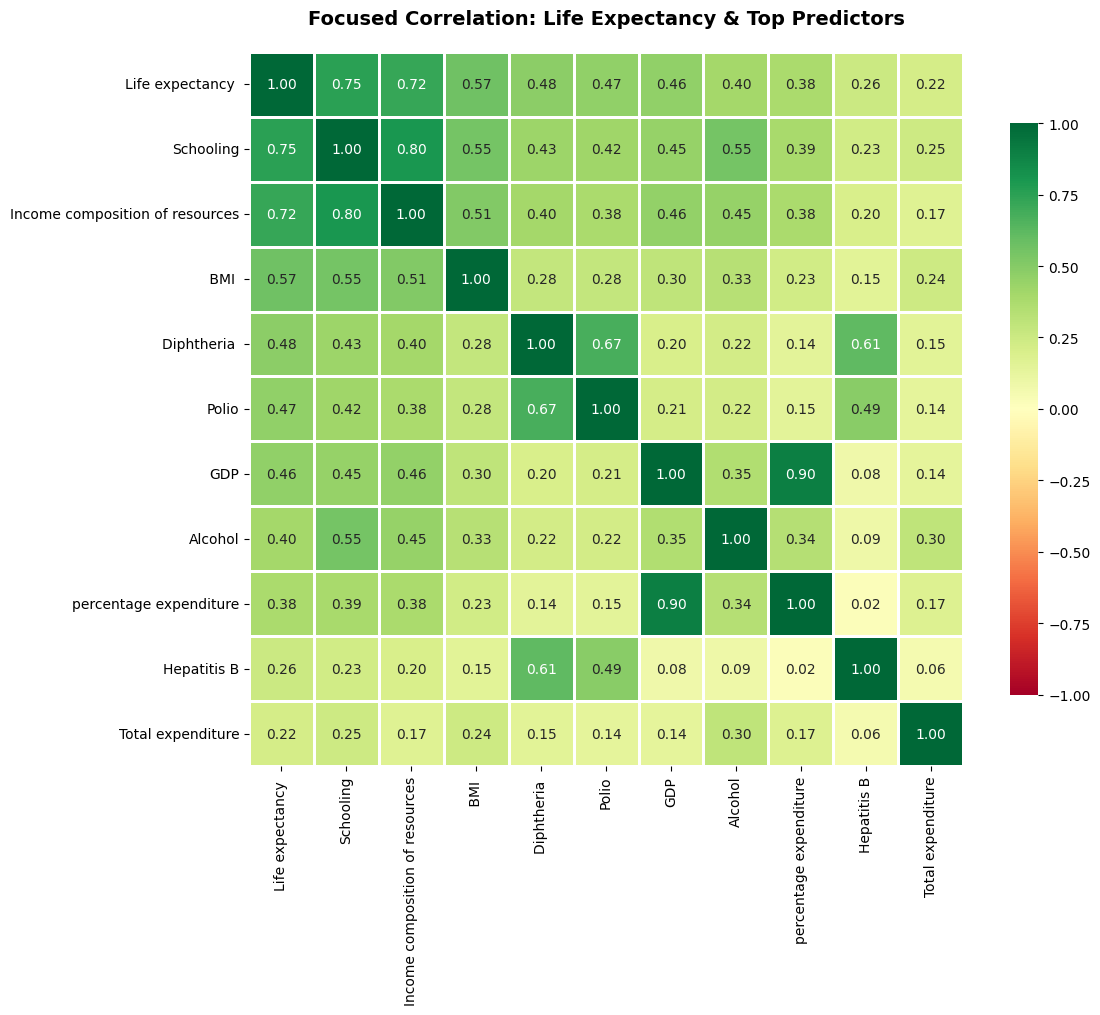


📈 VISUALIZING TOP RELATIONSHIPS:


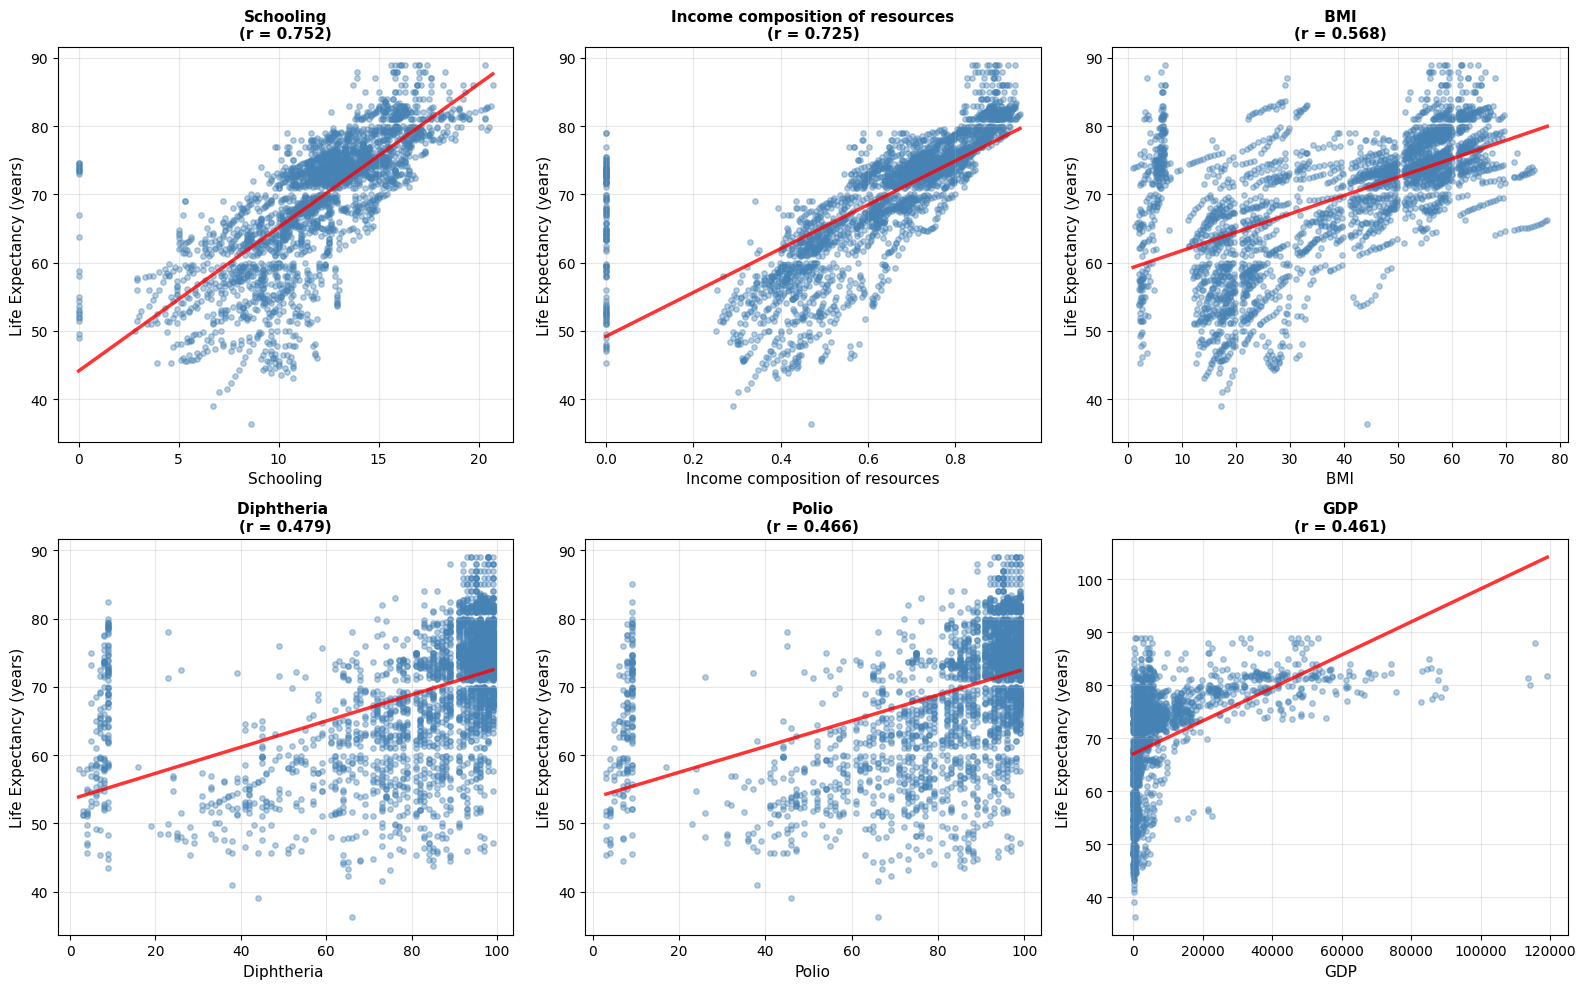


⚠️  MULTICOLLINEARITY CHECK:
Variables that are highly correlated with EACH OTHER (|r| > 0.8):
(This could cause problems in regression)

   infant deaths ↔ under-five deaths : 0.997
   percentage expenditure ↔ GDP: 0.899
    thinness  1-19 years ↔  thinness 5-9 years: 0.939
   Income composition of resources ↔ Schooling: 0.800

   Found 4 highly correlated pairs
   → May need to remove one variable from each pair

✅ STEP 2D COMPLETE!

NEXT STEP: Build the linear regression model!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("STEP 2D: CORRELATION ANALYSIS")
print("="*80)

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

print(f"\n📊 Analyzing {len(numeric_df.columns)} numeric variables")

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Get correlations with Life expectancy
life_exp_corr = correlation_matrix['Life expectancy '].sort_values(ascending=False)

print("\n🎯 TOP 10 POSITIVE CORRELATIONS with Life Expectancy:")
print(life_exp_corr.head(11)[1:])  # Exclude self-correlation

print("\n⚠️  TOP 5 NEGATIVE CORRELATIONS with Life Expectancy:")
print(life_exp_corr.tail(5))

# Identify strong correlations (threshold: |r| > 0.5)
strong_positive = life_exp_corr[(life_exp_corr > 0.5) & (life_exp_corr < 1.0)]
strong_negative = life_exp_corr[life_exp_corr < -0.5]

print(f"\n✅ {len(strong_positive)} variables with STRONG POSITIVE correlation (r > 0.5):")
for var, corr in strong_positive.items():
    print(f"   {var}: {corr:.3f}")

print(f"\n❌ {len(strong_negative)} variables with STRONG NEGATIVE correlation (r < -0.5):")
for var, corr in strong_negative.items():
    print(f"   {var}: {corr:.3f}")

# Full correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Matrix - All Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Focused heatmap: Life expectancy with top correlations
top_vars = life_exp_corr.index[:11]  # Top 10 + Life expectancy itself
focused_corr = correlation_matrix.loc[top_vars, top_vars]

plt.figure(figsize=(12, 10))
sns.heatmap(focused_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Focused Correlation: Life Expectancy & Top Predictors',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Scatter plots: Top 6 correlations
print("\n📈 VISUALIZING TOP RELATIONSHIPS:")
top_6_vars = life_exp_corr.index[1:7]  # Top 6 excluding self

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, var in enumerate(top_6_vars):
    # Scatter plot
    axes[idx].scatter(df[var], df['Life expectancy '], alpha=0.4, s=15, color='steelblue')

    # Add trend line
    mask = df[var].notna() & df['Life expectancy '].notna()
    if mask.sum() > 0:
        z = np.polyfit(df[var][mask], df['Life expectancy '][mask], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[var][mask].min(), df[var][mask].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r-", linewidth=2.5, alpha=0.8)

    axes[idx].set_xlabel(var, fontsize=11)
    axes[idx].set_ylabel('Life Expectancy (years)', fontsize=11)
    axes[idx].set_title(f'{var}\n(r = {life_exp_corr[var]:.3f})',
                       fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check for multicollinearity among predictors
print("\n⚠️  MULTICOLLINEARITY CHECK:")
print("Variables that are highly correlated with EACH OTHER (|r| > 0.8):")
print("(This could cause problems in regression)\n")

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            corr_val = correlation_matrix.iloc[i, j]
            high_corr_pairs.append((var1, var2, corr_val))
            print(f"   {var1} ↔ {var2}: {corr_val:.3f}")

if len(high_corr_pairs) == 0:
    print("   ✅ No severe multicollinearity detected!")
else:
    print(f"\n   Found {len(high_corr_pairs)} highly correlated pairs")
    print("   → May need to remove one variable from each pair")

print("\n" + "="*80)
print("✅ STEP 2D COMPLETE!")
print("\nNEXT STEP: Build the linear regression model!")
print("="*80)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("="*80)
print("STEP 3: DATA PREPARATION FOR MODELING")
print("="*80)

# ============================================================================
# STEP 3A: HANDLE MISSING VALUES
# ============================================================================
print("\n📊 STEP 3A: HANDLING MISSING VALUES")
print("-"*80)

print("Missing values before cleaning:")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

# Strategy 1: Drop rows with missing Life expectancy (target variable)
df_clean = df[df['Life expectancy '].notna()].copy()
print(f"\nDropped {len(df) - len(df_clean)} rows with missing target variable")
print(f"Remaining rows: {len(df_clean)}")

# Strategy 2: For predictors, we'll drop rows with ANY missing values
# (Alternative: could use imputation, but this is simpler for first model)
df_clean = df_clean.dropna()
print(f"\nAfter removing all rows with missing values: {len(df_clean)} rows")

print("\n✅ No missing values remaining!")

# ============================================================================
# STEP 3B: REMOVE MULTICOLLINEAR VARIABLES
# ============================================================================
print("\n\n🔧 STEP 3B: REMOVING MULTICOLLINEAR VARIABLES")
print("-"*80)

# Based on correlation analysis, remove one from each highly correlated pair:
variables_to_drop = [
    'under-five deaths ',  # Keep 'infant deaths' instead
    'percentage expenditure',  # Keep 'GDP' instead
    ' thinness 5-9 years',  # Keep ' thinness  1-19 years' instead
]

print("Dropping these variables due to multicollinearity:")
for var in variables_to_drop:
    if var in df_clean.columns:
        print(f"   ❌ {var}")
        df_clean = df_clean.drop(columns=[var])

print("\n✅ Multicollinearity reduced!")

# ============================================================================
# STEP 3C: PREPARE FEATURES AND TARGET
# ============================================================================
print("\n\n📋 STEP 3C: PREPARING FEATURES AND TARGET")
print("-"*80)

# Remove non-predictive columns
non_predictive = ['Country', 'Year']  # We can add Year back later if needed
print(f"\nRemoving non-predictive columns: {non_predictive}")

# Separate features (X) and target (y)
X = df_clean.drop(columns=['Life expectancy '] + non_predictive)
y = df_clean['Life expectancy ']

print(f"\n✅ Features (X): {X.shape[0]} rows × {X.shape[1]} columns")
print(f"✅ Target (y): {y.shape[0]} values")

print(f"\nFeature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2}. {col}")

# ============================================================================
# STEP 3D: HANDLE CATEGORICAL VARIABLE (Status)
# ============================================================================
print("\n\n🏷️  STEP 3D: ENCODING CATEGORICAL VARIABLE")
print("-"*80)

# Convert 'Status' to dummy variable (0/1)
if 'Status' in X.columns:
    print("Converting 'Status' (Developed/Developing) to binary variable:")
    print(f"   Before: {X['Status'].value_counts().to_dict()}")

    # Create dummy variable: 1 = Developed, 0 = Developing
    X['Status_Developed'] = (X['Status'] == 'Developed').astype(int)
    X = X.drop(columns=['Status'])

    print(f"   After: Status_Developed (1=Developed, 0=Developing)")
    print(f"   Distribution: {X['Status_Developed'].value_counts().to_dict()}")

print("\n✅ All variables are now numeric!")

# ============================================================================
# STEP 3E: TRAIN-TEST SPLIT
# ============================================================================
print("\n\n✂️  STEP 3E: SPLITTING DATA (80% TRAIN, 20% TEST)")
print("-"*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nTraining set statistics:")
print(f"   Life expectancy mean: {y_train.mean():.2f} years")
print(f"   Life expectancy std: {y_train.std():.2f} years")

print("\nTest set statistics:")
print(f"   Life expectancy mean: {y_test.mean():.2f} years")
print(f"   Life expectancy std: {y_test.std():.2f} years")

# ============================================================================
# STEP 3F: FEATURE SCALING (OPTIONAL BUT RECOMMENDED)
# ============================================================================
print("\n\n📏 STEP 3F: FEATURE SCALING")
print("-"*80)
print("Note: Scaling doesn't change results for linear regression,")
print("but helps with interpretation and numerical stability.")

# Save column names
feature_names = X_train.columns.tolist()

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print("✅ Features scaled to mean=0, std=1")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n\n" + "="*80)
print("✅ DATA PREPARATION COMPLETE!")
print("="*80)
print(f"\nFinal dataset:")
print(f"   Training: {X_train.shape[0]} rows × {X_train.shape[1]} features")
print(f"   Testing: {X_test.shape[0]} rows × {X_test.shape[1]} features")
print(f"   Target range: {y.min():.1f} - {y.max():.1f} years")

print(f"\nFeatures ready for modeling ({len(feature_names)}):")
for i, col in enumerate(feature_names, 1):
    print(f"   {i:2}. {col}")

print("\n🚀 READY TO BUILD LINEAR REGRESSION MODEL!")
print("="*80)

STEP 3: DATA PREPARATION FOR MODELING

📊 STEP 3A: HANDLING MISSING VALUES
--------------------------------------------------------------------------------
Missing values before cleaning:
Life expectancy                     10
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
 BMI                                34
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

Dropped 10 rows with missing target variable
Remaining rows: 2928

After removing all rows with missing values: 1649 rows

✅ No missing values remaining!


🔧 STEP 3B: REMOVING MULTICOLLINEAR VARIABLES
----------------------------------------------------

STEP 4: BUILDING INITIAL LINEAR REGRESSION MODEL

📊 STEP 4A: FITTING MODEL WITH ALL 16 PREDICTORS
--------------------------------------------------------------------------------

REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:       Life expectancy    R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     400.1
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        06:43:41   Log-Likelihood:                -3579.1
No. Observations:                1319   AIC:                             7192.
Df Residuals:                    1302   BIC:                             7280.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
           

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


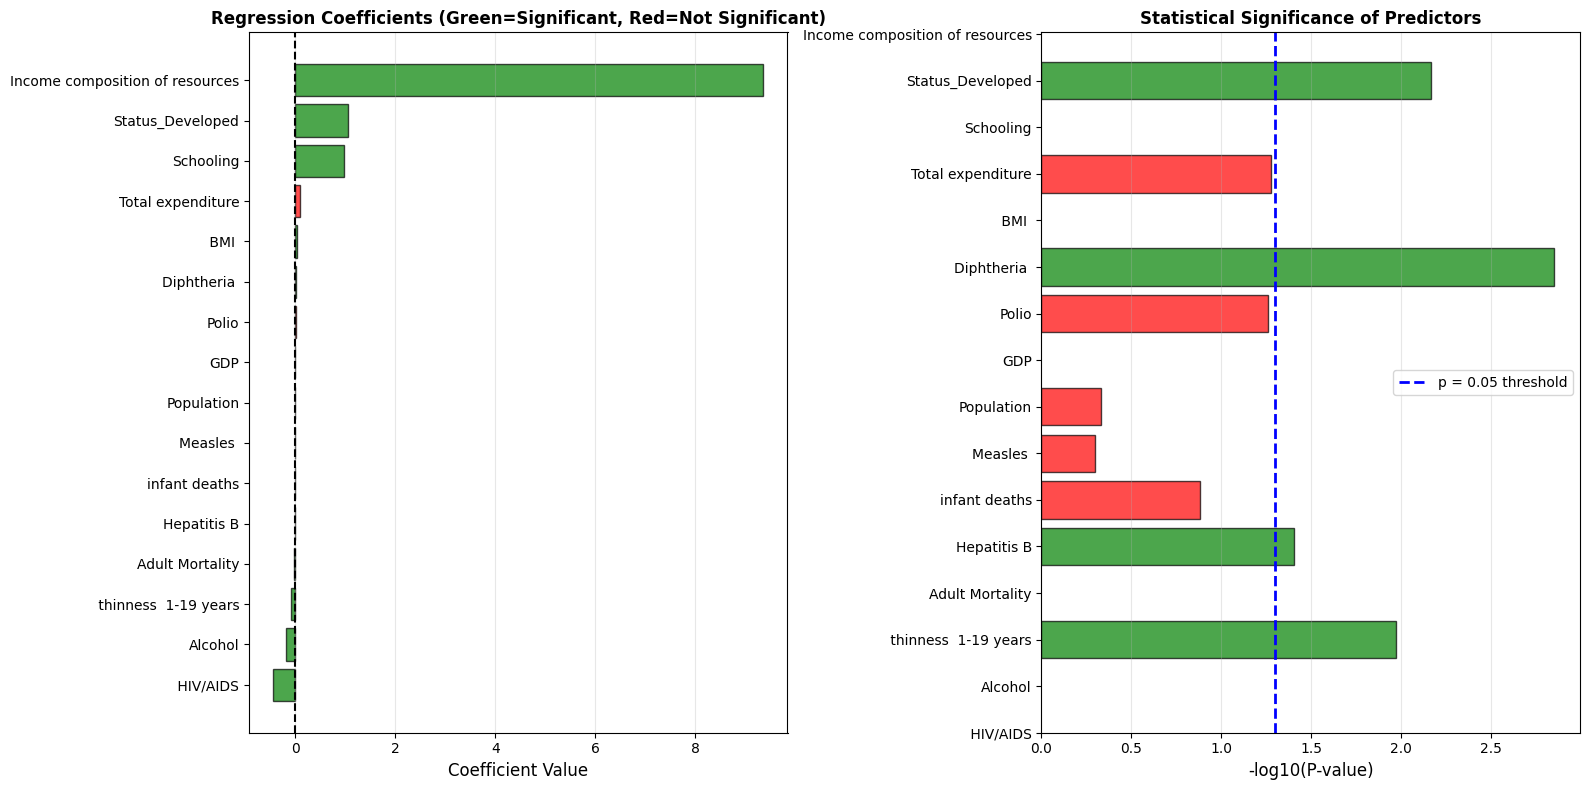



CHECKING LINEAR REGRESSION ASSUMPTIONS


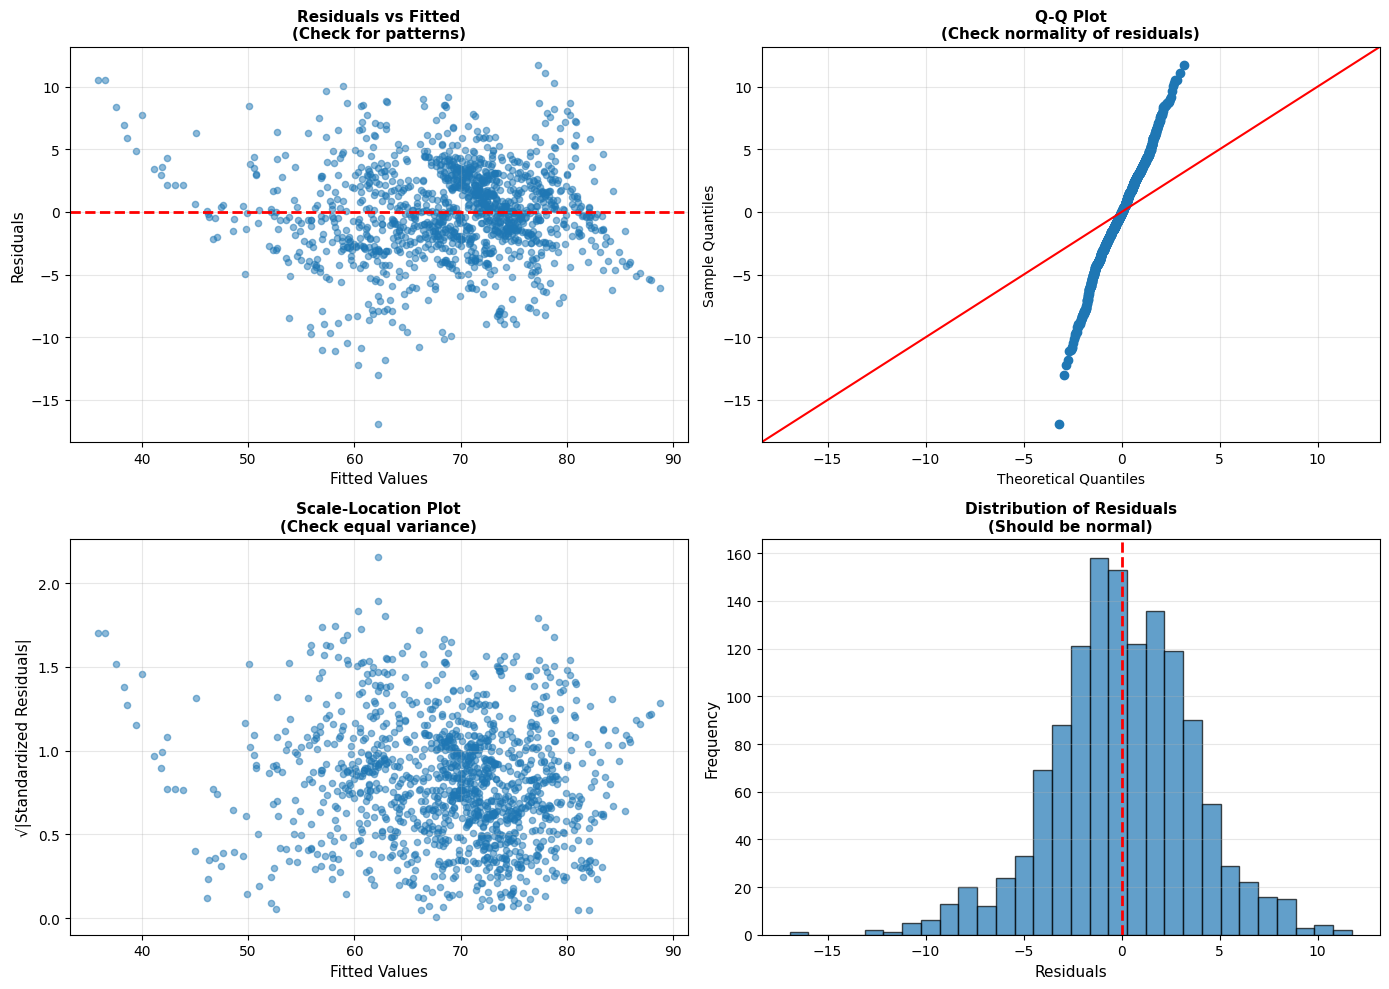


🔬 ASSUMPTION TESTS:

1. Normality of Residuals (Shapiro-Wilk Test):
   P-value: 0.0000
   ⚠️  Residuals are NOT normally distributed (p < 0.05)
       (This is often okay for large samples)

2. Autocorrelation (Durbin-Watson Test):
   DW statistic: 2.064
   Interpretation: 2 = no autocorrelation, <2 = positive, >2 = negative
   ✅ No significant autocorrelation


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("STEP 4: BUILDING INITIAL LINEAR REGRESSION MODEL")
print("="*80)

# ============================================================================
# STEP 4A: BUILD MODEL WITH ALL VARIABLES
# ============================================================================
print("\n📊 STEP 4A: FITTING MODEL WITH ALL 16 PREDICTORS")
print("-"*80)

# Add constant (intercept) for statsmodels
X_train_with_const = sm.add_constant(X_train)
X_test_with_const = sm.add_constant(X_test)

# Fit the model
model = sm.OLS(y_train, X_train_with_const).fit()

# Print the full summary
print("\n" + "="*80)
print("REGRESSION SUMMARY")
print("="*80)
print(model.summary())

# ============================================================================
# STEP 4B: KEY METRICS INTERPRETATION
# ============================================================================
print("\n\n" + "="*80)
print("KEY METRICS INTERPRETATION")
print("="*80)

print(f"\n📈 MODEL FIT:")
print(f"   R-squared: {model.rsquared:.4f}")
print(f"      → Model explains {model.rsquared*100:.2f}% of variance in life expectancy")

print(f"\n   Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"      → Adjusted for number of predictors: {model.rsquared_adj*100:.2f}%")

print(f"\n   F-statistic: {model.fvalue:.2f}")
print(f"   Prob (F-statistic): {model.f_pvalue:.2e}")
if model.f_pvalue < 0.05:
    print(f"      ✅ Model is statistically significant (p < 0.05)")
else:
    print(f"      ❌ Model is NOT significant (p >= 0.05)")

print(f"\n📊 MODEL ERROR:")
print(f"   Root Mean Squared Error (RMSE): {np.sqrt(model.mse_resid):.3f} years")
print(f"   Mean Absolute Error (MAE): {np.mean(np.abs(model.resid)):.3f} years")

# ============================================================================
# STEP 4C: COEFFICIENT ANALYSIS
# ============================================================================
print("\n\n" + "="*80)
print("COEFFICIENT ANALYSIS")
print("="*80)

# Create coefficient summary
coef_summary = pd.DataFrame({
    'Coefficient': model.params,
    'Std Error': model.bse,
    't-value': model.tvalues,
    'P-value': model.pvalues,
    'Significant': model.pvalues < 0.05
}).round(4)

# Exclude constant for easier reading
coef_summary_features = coef_summary.drop('const').sort_values('P-value')

print("\n🎯 SIGNIFICANT PREDICTORS (p < 0.05):")
significant = coef_summary_features[coef_summary_features['Significant']]
for idx, row in significant.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"\n   {idx}:")
    print(f"      Coefficient: {row['Coefficient']:.4f}")
    print(f"      P-value: {row['P-value']:.4f}")
    print(f"      → Each unit increase {direction} life expectancy by {abs(row['Coefficient']):.3f} years")

print(f"\n\n⚠️  NON-SIGNIFICANT PREDICTORS (p >= 0.05):")
non_significant = coef_summary_features[~coef_summary_features['Significant']]
if len(non_significant) > 0:
    for idx, row in non_significant.iterrows():
        print(f"   {idx}: p = {row['P-value']:.4f}")
else:
    print("   ✅ All predictors are significant!")

# ============================================================================
# STEP 4D: VISUALIZE COEFFICIENTS
# ============================================================================
print("\n\n📊 VISUALIZING COEFFICIENTS...")

# Exclude constant
coef_viz = coef_summary.drop('const').sort_values('Coefficient')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Coefficient magnitudes with significance
colors = ['green' if p < 0.05 else 'red' for p in coef_viz['P-value']]
axes[0].barh(range(len(coef_viz)), coef_viz['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(coef_viz)))
axes[0].set_yticklabels(coef_viz.index)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Regression Coefficients (Green=Significant, Red=Not Significant)',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: P-values
axes[1].barh(range(len(coef_viz)), -np.log10(coef_viz['P-value']),
             color=['green' if p < 0.05 else 'red' for p in coef_viz['P-value']],
             alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(coef_viz)))
axes[1].set_yticklabels(coef_viz.index)
axes[1].axvline(x=-np.log10(0.05), color='blue', linestyle='--', linewidth=2,
                label='p = 0.05 threshold')
axes[1].set_xlabel('-log10(P-value)', fontsize=12)
axes[1].set_title('Statistical Significance of Predictors', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 4E: MODEL ASSUMPTIONS CHECK
# ============================================================================
print("\n\n" + "="*80)
print("CHECKING LINEAR REGRESSION ASSUMPTIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted (Linearity & Homoscedasticity)
axes[0, 0].scatter(model.fittedvalues, model.resid, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Residuals vs Fitted\n(Check for patterns)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot (Normality of Residuals)
sm.qqplot(model.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot\n(Check normality of residuals)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Scale-Location Plot (Homoscedasticity)
standardized_resid = model.resid / np.std(model.resid)
axes[1, 0].scatter(model.fittedvalues, np.sqrt(np.abs(standardized_resid)), alpha=0.5, s=20)
axes[1, 0].set_xlabel('Fitted Values', fontsize=11)
axes[1, 0].set_ylabel('√|Standardized Residuals|', fontsize=11)
axes[1, 0].set_title('Scale-Location Plot\n(Check equal variance)', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Histogram of Residuals
axes[1, 1].hist(model.resid, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of Residuals\n(Should be normal)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical tests for assumptions
print("\n🔬 ASSUMPTION TESTS:")

# Normality test
shapiro_stat, shapiro_p = stats.shapiro(model.resid[:5000])  # Sample if too large
print(f"\n1. Normality of Residuals (Shapiro-Wilk Test):")
print(f"   P-value: {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print(f"   ⚠️  Residuals are NOT normally distributed (p < 0.05)")
    print(f"       (This is often okay for large samples)")
else:
    print(f"   ✅ Residuals appear normally distributed (p >= 0.05)")

# Durbin-Watson test for autocorrelation
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(model.resid)
print(f"\n2. Autocorrelation (Durbin-Watson Test):")
print(f"   DW statistic: {dw:.3f}")
print(f"   Interpretation: 2 = no autocorrelation, <2 = positive, >2 = negative")
if 1.5 < dw < 2.5:
    print(f"   ✅ No significant autocorrelation")
else:
    print(f"   ⚠️  Possible autocorrelation detected")
